<a href="https://colab.research.google.com/github/ghizlane89/0__GenIA/blob/Bootcamp/W6_D5_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')


import pandas as pd

file_path = "/content/drive/MyDrive/Datasets/tennis_articles.csv"
df = pd.read_csv(file_path,encoding='latin-1')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,article_id,article_title,article_text,source
0,1,"I do not have friends in tennis, says Maria Sh...",Maria Sharapova has basically no friends as te...,https://www.tennisworldusa.org/tennis/news/Mar...
1,2,Federer defeats Medvedev to advance to 14th Sw...,"BASEL, Switzerland (AP)  Roger Federer advanc...",http://www.tennis.com/pro-game/2018/10/copil-s...
2,3,Tennis: Roger Federer ignored deadline set by ...,Roger Federer has revealed that organisers of ...,https://scroll.in/field/899938/tennis-roger-fe...
3,4,Nishikori to face off against Anderson in Vien...,Kei Nishikori will try to end his long losing ...,http://www.tennis.com/pro-game/2018/10/nishiko...
4,5,Roger Federer has made this huge change to ten...,"Federer, 37, first broke through on tour over ...",https://www.express.co.uk/sport/tennis/1036101...


In [4]:
# Informations générales sur les colonnes
print("\nInformations sur le DataFrame :")
print(df.info())

# Suppression de 'article_title' si présente
if 'article_title' in df.columns:
    df = df.drop(columns=['article_title'])
    print("\nColonne 'article_title' supprimée.")

# Vérification finale
print("\nAperçu après suppression éventuelle :")
print(df.head())


Informations sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   article_id     8 non-null      int64 
 1   article_title  8 non-null      object
 2   article_text   8 non-null      object
 3   source         8 non-null      object
dtypes: int64(1), object(3)
memory usage: 388.0+ bytes
None

Colonne 'article_title' supprimée.

Aperçu après suppression éventuelle :
   article_id                                       article_text  \
0           1  Maria Sharapova has basically no friends as te...   
1           2  BASEL, Switzerland (AP)  Roger Federer advanc...   
2           3  Roger Federer has revealed that organisers of ...   
3           4  Kei Nishikori will try to end his long losing ...   
4           5  Federer, 37, first broke through on tour over ...   

                                              source  
0  https:/

In [5]:

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

Voici une version fonctionnelle sans NLTK, en utilisant split basique avec la ponctuation. C’est moins précis mais 100% fonctionnel et rapide :

In [6]:
import re

# Partie 2 alternative : Tokenisation basique sans NLTK

sentences = []

# Découpage des articles avec split sur . ? !
for article in df['article_text']:
    phrases = re.split(r'[.?!]\s*', str(article))
    sentences.extend(phrases)

# Nettoyage : suppression des vides
sentences = [s.strip() for s in sentences if s.strip() != '']

print(f"Nombre total de phrases : {len(sentences)}")
print("\nExemples de phrases :")
print(sentences[:5])


Nombre total de phrases : 143

Exemples de phrases :
['Maria Sharapova has basically no friends as tennis players on the WTA Tour', "The Russian player has no problems in openly speaking about it and in a recent interview she said: 'I don't really hide any feelings too much", 'I think everyone knows this is my job here', "When I'm on the courts or when I'm on the court playing, I'm a competitor and I want to beat every single person whether they're in the locker room or across the net", "So I'm not the one to strike up a conversation about the weather and know that in the next few minutes I have to go and try to win a tennis match"]


Partie 3 : téléchargement et chargement des vecteurs GloVe.

In [8]:
import os
import numpy as np

# Nom du fichier GloVe
glove_file = "glove.6B.100d.txt"

# 📥 Téléchargement si le fichier n'existe pas déjà
if not os.path.exists(glove_file):
    print("Téléchargement de GloVe...")
    !wget http://nlp.stanford.edu/data/glove.6B.zip
    print("Décompression...")
    !unzip glove.6B.zip
else:
    print("Fichier GloVe déjà présent.")

# 📦 Chargement des vecteurs GloVe
embeddings_index = {}
print("Chargement de GloVe en mémoire...")

with open(glove_file, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

print(f"Nombre total de mots dans GloVe : {len(embeddings_index)}")
print(f"Exemple de vecteur pour 'tennis' : {embeddings_index.get('tennis')}")



Téléchargement de GloVe...
--2025-08-12 09:15:35--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-08-12 09:15:35--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-08-12 09:15:35--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Savi

partie 4 : nettoyage et normalisation du texte.

In [9]:
import re
from nltk.corpus import stopwords

# Téléchargement stopwords anglais
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def nettoyer_phrase(phrase):
    # Minuscule
    phrase = phrase.lower()
    # Supprimer chiffres et ponctuations
    phrase = re.sub(r'[^a-zA-Z\s]', '', phrase)
    # Supprimer les mots vides
    mots = phrase.split()
    mots = [mot for mot in mots if mot not in stop_words]
    # Recréer la phrase nettoyée
    return ' '.join(mots)

# Nettoyage de toutes les phrases
clean_sentences = [nettoyer_phrase(phrase) for phrase in sentences]

print(f"\nExemples après nettoyage : {clean_sentences[:5]}")



Exemples après nettoyage : ['maria sharapova basically friends tennis players wta tour', 'russian player problems openly speaking recent interview said dont really hide feelings much', 'think everyone knows job', 'im courts im court playing im competitor want beat every single person whether theyre locker room across net', 'im one strike conversation weather know next minutes go try win tennis match']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Partie 5 : vectorisation des phrases.

In [10]:
def vectoriser_phrase(phrase, embeddings_index, dim=100):
    mots = phrase.split()
    vecteurs = []
    for mot in mots:
        vecteur = embeddings_index.get(mot)
        if vecteur is not None:
            vecteurs.append(vecteur)
    if vecteurs:
        return np.mean(vecteurs, axis=0)
    else:
        return np.zeros(dim)

# Vectorisation de toutes les phrases
sentence_vectors = [vectoriser_phrase(phrase, embeddings_index) for phrase in clean_sentences]

print(f"\nNombre de phrases vectorisées : {len(sentence_vectors)}")
print(f"Dimension d'un vecteur : {len(sentence_vectors[0])}")



Nombre de phrases vectorisées : 143
Dimension d'un vecteur : 100


partie 6 : construction de la matrice de similarité.

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

import numpy as np

# Initialisation d'une matrice de zéros
nb_phrases = len(sentence_vectors)
similarity_matrix = np.zeros((nb_phrases, nb_phrases))

# Remplissage de la matrice par similarité cosinus
for i in range(nb_phrases):
    for j in range(nb_phrases):
        if i != j:
            similarity_matrix[i][j] = cosine_similarity(
                sentence_vectors[i].reshape(1, -1),
                sentence_vectors[j].reshape(1, -1)
            )[0, 0]

print("\nMatrice de similarité construite !")
print(f"Forme de la matrice : {similarity_matrix.shape}")



Matrice de similarité construite !
Forme de la matrice : (143, 143)


In [12]:
import pandas as pd

# Conversion en DataFrame pour affichage lisible
similarity_df = pd.DataFrame(similarity_matrix)

# Affichage des premières lignes de la matrice
print("\nAperçu de la matrice de similarité :")
print(similarity_df.head())

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(similarity_df)



Aperçu de la matrice de similarité :
        0         1         2         3         4         5         6    \
0  0.000000  0.642697  0.591570  0.726268  0.772794  0.659803  0.657144   
1  0.642697  0.000000  0.855736  0.813412  0.830143  0.674890  0.804851   
2  0.591570  0.855736  0.000000  0.789130  0.797251  0.702327  0.724386   
3  0.726268  0.813412  0.789130  0.000000  0.887827  0.816139  0.830462   
4  0.772794  0.830143  0.797251  0.887827  0.000000  0.713493  0.804397   

        7         8         9    ...       133       134       135       136  \
0  0.720573  0.685422  0.647395  ...  0.719613  0.655674  0.644660  0.577963   
1  0.829982  0.810703  0.911276  ...  0.635516  0.756759  0.909717  0.796951   
2  0.772859  0.800836  0.893341  ...  0.573603  0.650575  0.893601  0.730206   
3  0.849207  0.844026  0.830503  ...  0.679540  0.735556  0.822710  0.677139   
4  0.854391  0.827298  0.864757  ...  0.753076  0.815289  0.851383  0.774661   

        137       138       13

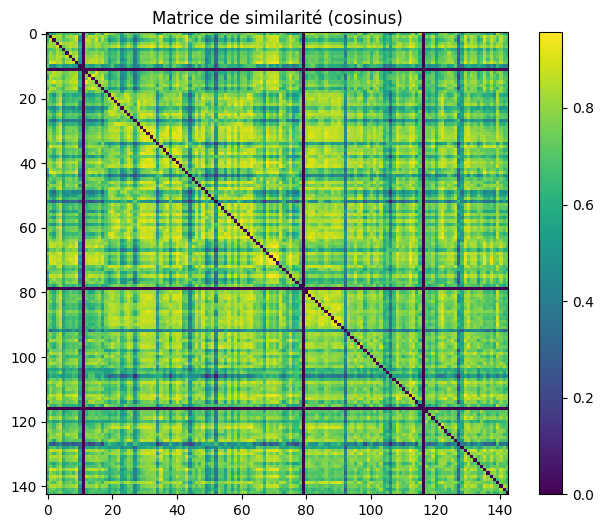

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(similarity_matrix, interpolation='nearest')
plt.colorbar()
plt.title('Matrice de similarité (cosinus)')
plt.show()


partie 7 : construction du graphe et application de PageRank.

In [14]:
import networkx as nx

# Création du graphe basé sur la matrice de similarité
graph = nx.from_numpy_array(similarity_matrix)

# Calcul des scores PageRank
scores = nx.pagerank(graph)

# Transformation en liste triée (phrases les plus importantes en haut)
ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)

# Aperçu : top 5 phrases
print("\nTop 5 phrases classées par PageRank :\n")
for i in range(5):
    print(f"{i+1}. {ranked_sentences[i][1]}")



Top 5 phrases classées par PageRank :

1. Major players feel that a big event in late November combined with one in January before the Australian Open will mean too much tennis and too little rest
2. So I'm not the one to strike up a conversation about the weather and know that in the next few minutes I have to go and try to win a tennis match
3. I felt like the best weeks that I had to get to know players when I was playing were the Fed Cup weeks or the Olympic weeks, not necessarily during the tournaments
4. Speaking at the Swiss Indoors tournament where he will play in Sundays final against Romanian qualifier Marius Copil, the world number three said that given the impossibly short time frame to make a decision, he opted out of any commitment
5. Exhausted after spending half his round deep in the bushes searching for my ball, as well as those of two other golfers hed never met before, our incredibly giving designated driver asked if we didnt mind going straight home after signi

partie 8 : génération du résumé final.

In [15]:
# Nombre de phrases pour le résumé
N = 10

# Sélection des N meilleures phrases selon PageRank
summary_sentences = [ranked_sentences[i][1] for i in range(N)]

# Résumé final sous forme de texte
resume = ' '.join(summary_sentences)

print("\nRésumé généré :\n")
print(resume)



Résumé généré :

Major players feel that a big event in late November combined with one in January before the Australian Open will mean too much tennis and too little rest So I'm not the one to strike up a conversation about the weather and know that in the next few minutes I have to go and try to win a tennis match I felt like the best weeks that I had to get to know players when I was playing were the Fed Cup weeks or the Olympic weeks, not necessarily during the tournaments Speaking at the Swiss Indoors tournament where he will play in Sundays final against Romanian qualifier Marius Copil, the world number three said that given the impossibly short time frame to make a decision, he opted out of any commitment Exhausted after spending half his round deep in the bushes searching for my ball, as well as those of two other golfers hed never met before, our incredibly giving designated driver asked if we didnt mind going straight home after signing off so he could rest up a little b

Exemples d’applications pratiques du résumé automatique avec le NLP

Médias et journalisme

Produire automatiquement des résumés d’articles de presse.

Générer des newsletters de manière automatisée.

Veille documentaire

Condenser des rapports volumineux (juridiques, scientifiques, techniques).

Aider les analystes à identifier rapidement les points essentiels sans lire l’intégralité des documents.

Support client

Résumer des échanges d’e-mails ou de tickets de support.

Synthétiser les retours et commentaires des clients.

Éducation

Résumer des chapitres de cours ou des ouvrages.

Fournir des supports de révision sous forme de résumés.

Secteur juridique

Condenser des décisions de justice ou des contrats complexes.

Entreprise et communication interne

Résumer des réunions à partir de leurs transcriptions.

Synthétiser des rapports ou comptes rendus d’activité.

En résumé : ce type de système permet de traiter rapidement de grands volumes de texte et d’en extraire les informations clés.

Bilan rapide
Réalisation d’un outil de résumé automatique reposant sur des méthodes classiques de NLP.

Pipeline complet : nettoyage des données ➡️ vectorisation avec GloVe ➡️ calcul des similarités ➡️ PageRank ➡️ production du résumé.

Résultat : un système simple, transparent et ne nécessitant pas de modèles complexes.

Conclusion
Ce projet illustre comment combiner des techniques éprouvées pour obtenir des résumés pertinents, tout en restant léger et explicable.
Pour traiter des textes plus longs ou variés, l’intégration de modèles LLM (type transformers) pourrait constituer une évolution intéressante.


